In [ ]:
# lib
import tensorflow as tf
from tensorflow import keras

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os

from PIL import Image
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

I0000 00:00:1780989238.659042   36937 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780989238.665146   36937 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780989239.182073   36937 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/tofu/.local/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the lat

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import datasets,layers,models
from tensorflow.keras.applications import MobileNetV2

### **Fashion Dataset**

In [ ]:
# baca styles.csv, skip line yang corrupt karena nanti error
df_styles = pd.read_csv("archive/fashion-dataset/styles.csv", on_bad_lines='skip')

df_styles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  object 
 2   masterCategory      44424 non-null  object 
 3   subCategory         44424 non-null  object 
 4   articleType         44424 non-null  object 
 5   baseColour          44409 non-null  object 
 6   season              44403 non-null  object 
 7   year                44423 non-null  float64
 8   usage               44107 non-null  object 
 9   productDisplayName  44417 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 3.4+ MB


In [ ]:
df_styles.dropna(subset=['productDisplayName'], inplace=True)
df_styles.isna().sum()

id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             10
season                 21
year                    1
usage                 312
productDisplayName      0
dtype: int64

In [ ]:
df_styles.head(5)

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [ ]:

cnt = 0
for r in df_styles['productDisplayName']:
    r = r.lower()
    print(r)
    r = r.replace('-', '')
    if ('tshirt' in r):
        cnt += 1

print(cnt)

Streaming output truncated to the last 5000 lines.
red tape men black shoes
park avenue men black sunglasses
numero uno men brown flip flops
enroute men leather brown formal shoes
fossil men blue dial chronograph watch fs4703
lotto men cross brown floater
peter england men statements brown wallet
gas men venice slipper
catwalk women wedding collection gold heels
maxima ssteele men white watch
gas men freetime red casual shoes
nike women dual fusion silver sports shoes
american tourister unisex green camera bag
mark taylor men printed off white t-shirt
myntra men's executive white t-shirt
deni yo men blue slim fit jeans
nike women dpt pink t-shirt
levitate men black belt
adidas men navy blue t-shirt
rocia women white sandals
allen solly woman green bangle
timberland men brown casual shoes
denizen men light blue jeans
u.s. polo assn. men solid ivory polo tshirt
arrow sport men brown striped t-shirt
nike women's tenkay slip red shoe
facit men charcoal brief
wrangler men grey t-shirt
fnf r

In [ ]:
np.unique(df_styles['articleType'])

array(['Accessory Gift Set', 'Baby Dolls', 'Backpacks', 'Bangle',
       'Basketballs', 'Bath Robe', 'Beauty Accessory', 'Belts', 'Blazers',
       'Body Lotion', 'Body Wash and Scrub', 'Booties', 'Boxers', 'Bra',
       'Bracelet', 'Briefs', 'Camisoles', 'Capris', 'Caps',
       'Casual Shoes', 'Churidar', 'Clothing Set', 'Clutches', 'Compact',
       'Concealer', 'Cufflinks', 'Cushion Covers', 'Deodorant', 'Dresses',
       'Duffel Bag', 'Dupatta', 'Earrings', 'Eye Cream', 'Eyeshadow',
       'Face Moisturisers', 'Face Scrub and Exfoliator',
       'Face Serum and Gel', 'Face Wash and Cleanser', 'Flats',
       'Flip Flops', 'Footballs', 'Formal Shoes', 'Foundation and Primer',
       'Fragrance Gift Set', 'Free Gifts', 'Gloves', 'Hair Accessory',
       'Hair Colour', 'Handbags', 'Hat', 'Headband', 'Heels',
       'Highlighter and Blush', 'Innerwear Vests', 'Ipad', 'Jackets',
       'Jeans', 'Jeggings', 'Jewellery Set', 'Jumpsuit',
       'Kajal and Eyeliner', 'Key chain', 'Kurta Se

In [ ]:
s = set()
for r in df_styles['usage']:
    s.add(r)

print(s)

{'Formal', 'Home', 'Ethnic', 'Casual', 'Smart Casual', 'Party', 'Travel', 'Sports', nan}


In [ ]:
formal = set()
casual = set()

for r in df_styles.itertuples():
    if (r.usage == 'Formal'):
        formal.add(r.articleType)
    elif (r.usage == 'Casual'):
        casual.add(r.articleType)

print("Formal:")
for f in formal:
    print("\t", f)

print('='*50)
print('='*50)

print("Casual")
for c in casual:
    print("\t", c)

Formal:
	 Formal Shoes
	 Shirts
	 Tshirts
	 Watches
	 Flats
	 Dresses
	 Cufflinks
	 Skirts
	 Casual Shoes
	 Trousers
	 Belts
	 Heels
	 Tops
	 Suspenders
	 Laptop Bag
	 Wallets
	 Blazers
	 Accessory Gift Set
	 Free Gifts
	 Handbags
	 Ties
	 Sandals
	 Socks
Casual
	 Hat
	 Rompers
	 Body Lotion
	 Lip Liner
	 Bra
	 Watches
	 Ring
	 Perfume and Body Mist
	 Track Pants
	 Concealer
	 Dresses
	 Skirts
	 Deodorant
	 Jackets
	 Tracksuits
	 Jewellery Set
	 Face Scrub and Exfoliator
	 Lounge Pants
	 Gloves
	 Heels
	 Mask and Peel
	 Kurtas
	 Tops
	 Beauty Accessory
	 Headband
	 Nail Essentials
	 Face Moisturisers
	 Body Wash and Scrub
	 Foundation and Primer
	 Robe
	 Blazers
	 Flip Flops
	 Face Wash and Cleanser
	 Tablet Sleeve
	 Booties
	 Earrings
	 Ipad
	 Kurtis
	 Flats
	 Trunk
	 Sweaters
	 Lipstick
	 Shoe Accessories
	 Camisoles
	 Umbrellas
	 Trousers
	 Stockings
	 Pendant
	 Mobile Pouch
	 Toner
	 Suits
	 Rain Jacket
	 Mens Grooming Kit
	 Shapewear
	 Lip Plumper
	 Lounge Shorts
	 Wristbands
	 Ka

Definisikan kelas formal upper body

In [ ]:
formal_up = [
    'Shirts', 'Suits', 'Blazer'
]

Definisikan kelas non-formal upper body

In [ ]:
nonformal_up = [
    'Tshirts'
]

Filter data, buang yang tidak perlu

In [ ]:
len(df_styles)

44417

In [ ]:
df_styles = df_styles[
    (df_styles['articleType'].isin(formal_up)) |
    ( df_styles['articleType'].isin(nonformal_up) )
]

print(len(df_styles))

for row in df_styles['productDisplayName']:
    row = row.lower()
    row = row.replace('-', '')
    if 'polo' in row or 'Polo' in row:
        print(row)

10285
puma men's stripe polo black tshirt
nike women purple polo tshirt
united colors of benetton men solid pink polo tshirts
classic polo men vulcan white polo tshirts
u.s. polo assn. men white & navy blue shirt
u.s. polo assn. men stripes black  polo tshirt
classic polo men stripes blue tshirts
ucb men's polo neck with lion logo navy blue tshirt
classic polo men's swiss yellow tshirt
arrow sport men solid white polo tshirts
adidas men stripe polo white polo tshirt
united colors of benetton men stripes red  polo tshirts
wrangler men polo charcoal tshirt
u.s. polo assn. men printed  steeple grey tshirt
u.s. polo assn. men solid navy blue tshirt
united colors of benetton men stripes black polo tshirts
classic polo men striped navy blue tshirt
basics men orange polo tshirt
classic polo men's grey red & brown stripe tshirt
arrow men yellow polo tshirt
classic polo men stripes black tshirts
classic polo men printed navy blue tshirt
u.s. polo assn. men stripes blue polo tshirt
puma men's fo

Pisahkan

In [ ]:
df_styles_formal = df_styles[
    (df_styles['articleType'].isin(formal_up))    ]



df_styles_nonformal = pd.read_csv("non_collared_tshirts_clean.csv")
df_styles_nonformal.drop(columns=['manual_label', 'imagePath'], inplace=True)


In [ ]:
# cek count
print(len(df_styles_formal) + len(df_styles_nonformal))

print("Jumlah data formal", len(df_styles_formal))
print("Jumlah data non-formal", len(df_styles_nonformal))



6137
Jumlah data formal 3218
Jumlah data non-formal 2919


Selisihnya 2x lipat lebih. Perlu menangani data imbalance

Sekarang keduanya sama-sama 3218


Ambil Path

In [ ]:
IMAGE_PATH = 'archive/fashion-dataset/images'

# ambil path
df_styles_formal['imagePath'] = IMAGE_PATH + '/' + df_styles_formal['id'].astype(str) + '.jpg'

df_styles_formal = df_styles_formal[ df_styles_formal['imagePath'].apply(os.path.exists) ]


print(len(df_styles_formal))


3215


/tmp/ipykernel_4867/2041827366.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_styles_formal['imagePath'] = IMAGE_PATH + '/' + df_styles_formal['id'].astype(str) + '.jpg'


In [ ]:
IMAGE_PATH = 'archive/fashion-dataset/images'

# ambil path
df_styles_nonformal['imagePath'] = IMAGE_PATH + '/' + df_styles_nonformal['id'].astype(str) + '.jpg'

df_styles_nonformal = df_styles_nonformal[ df_styles_nonformal['imagePath'].apply(os.path.exists) ]


print(len(df_styles_nonformal))


2919


Labeli 1 per 1

### **Clothes Dataset**

Kelas Formal

In [ ]:
formal_up2 = [
    'Blazer', 'Kemeja', 'Polo'
]

Kelas Casual

In [ ]:
nonformal_up2 = [
    'Hoodie', 'Sweter', 'Kaos'
]

Dapatkan path image

In [ ]:
formal_path = []


for x in formal_up2:
    path = f"archive/Clothes_Dataset/{x}"
    for f in os.listdir(path):
        formal_path.append(path + '/' + f)


print(len(formal_path))

1500


In [ ]:
nonformal_path = []


for x in nonformal_up2:
    path = f"archive/Clothes_Dataset/{x}"

    for f in os.listdir(path):
        nonformal_path.append(path + '/' + f)

print(len(nonformal_path))

1500


**Satukan semua image path dari dua dataset**

In [ ]:
for r in df_styles_formal['imagePath']:
    formal_path.append(r)

print(len(formal_path))

4715


In [ ]:
for r in df_styles_nonformal['imagePath']:
    nonformal_path.append(r)

print(len(nonformal_path))

4419


EDA Selesai


Ya

**Pembangunan Model Klasifikasi Upper Body**

In [ ]:
df_formal = pd.DataFrame({
    "image": formal_path,
    "label": 1
})

In [ ]:
print(df_formal.head(3))

                                               image  label
0  archive/Clothes_Dataset/Blazer/blazzer_abu_abu...      1
1  archive/Clothes_Dataset/Blazer/blazzer_stradiv...      1
2  archive/Clothes_Dataset/Blazer/blazzer_merah_1...      1


In [ ]:
df_nonformal = pd.DataFrame({
    "image": nonformal_path,
    'label': 0
})

In [ ]:
print(df_nonformal.head(3))


                                               image  label
0  archive/Clothes_Dataset/Hoodie/hoodie_nike_sb_...      0
1  archive/Clothes_Dataset/Hoodie/hoodie_nike_169...      0
2  archive/Clothes_Dataset/Hoodie/hoodie_move_169...      0


In [ ]:
df = pd.concat([df_formal, df_nonformal], ignore_index=True)

In [ ]:
print(len(df))

9134


In [ ]:

df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    train_size=0.8,
    shuffle=True,
    stratify=df['label'],
    random_state=42
)

In [ ]:
len(df_train)

7307

In [ ]:
len(df_test)

1827

In [ ]:
df_train.value_counts('label')

label
1    3772
0    3535
Name: count, dtype: int64

In [ ]:
df_test.value_counts('label')

label
1    943
0    884
Name: count, dtype: int64

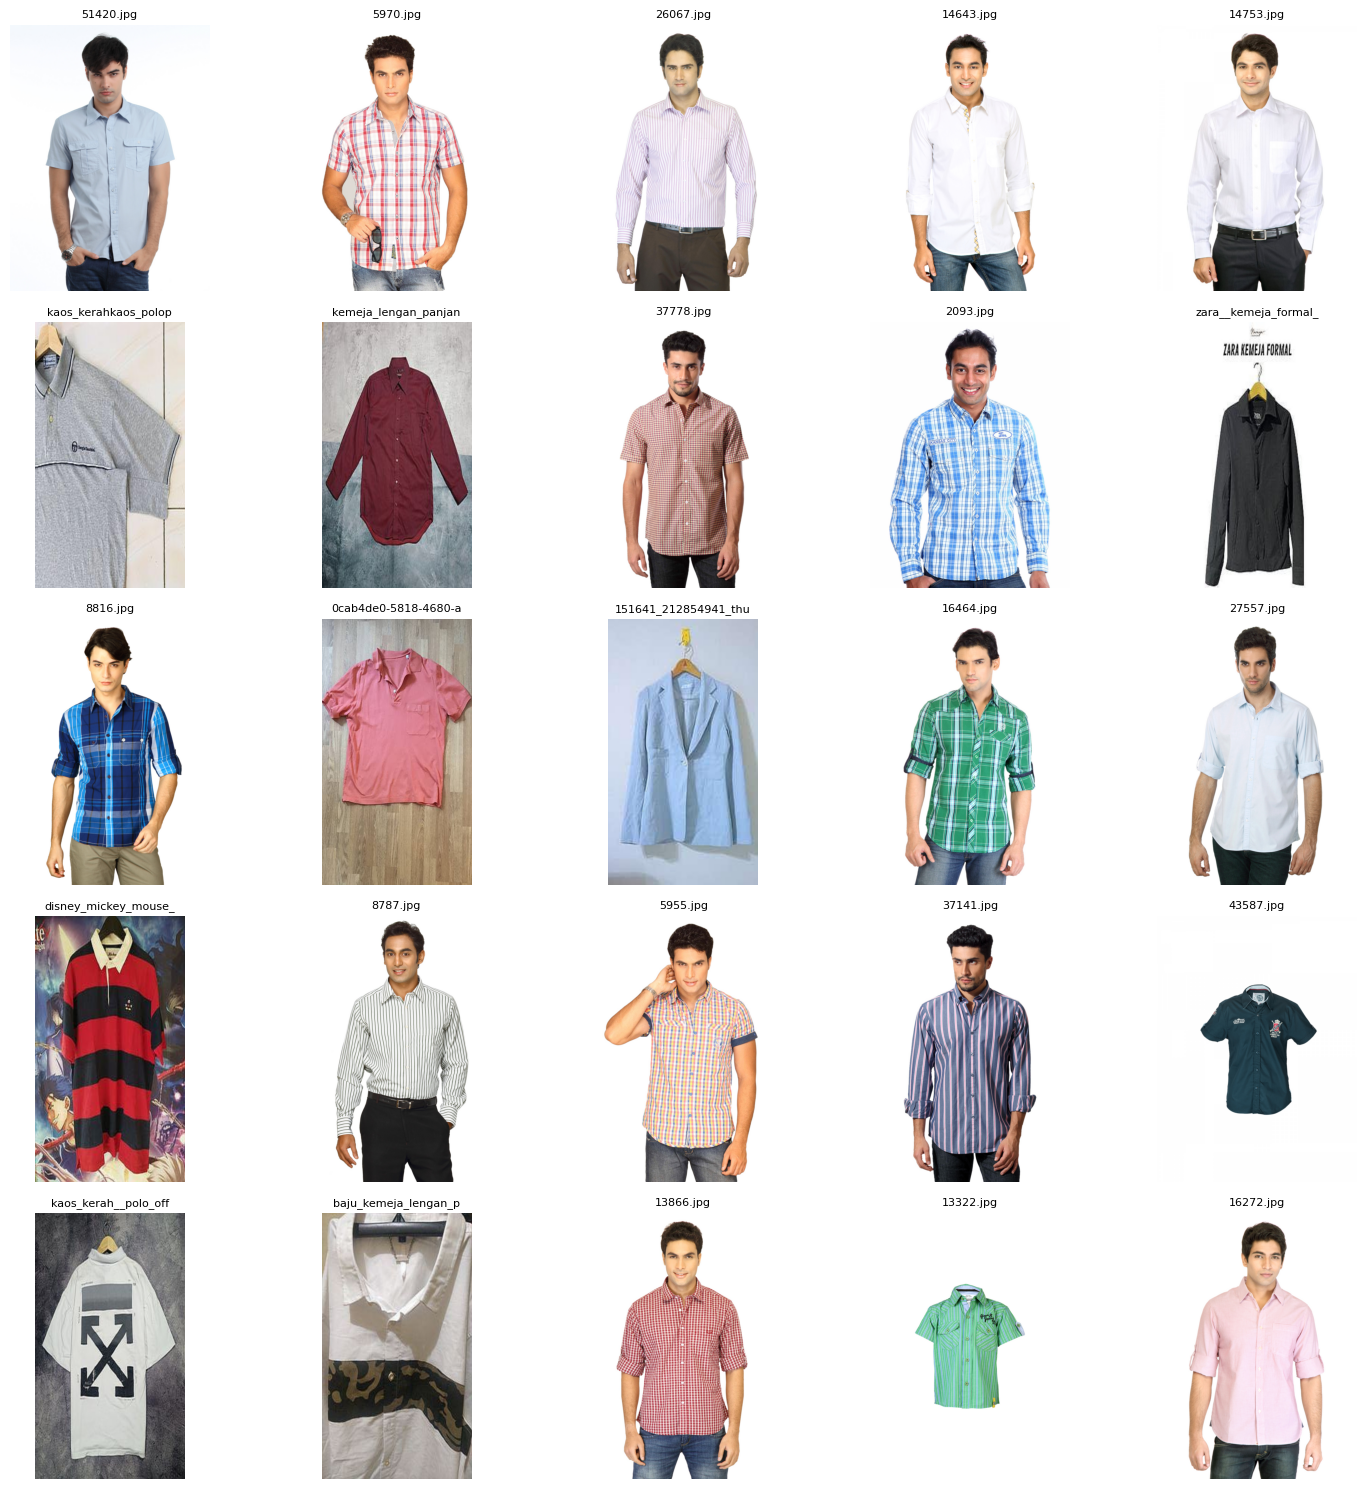

In [ ]:


sample = df[df['label'] == 1].sample(25, random_state=26)

plt.figure(figsize=(15, 15))

for i in range(len(sample)):
    plt.subplot(5, 5, i + 1)

    row = sample.iloc[i]

    img = Image.open(row['image'])

    plt.imshow(img)
    plt.title(
        os.path.basename(row['image'])[:20],
        fontsize=8
    )
    plt.axis('off')

plt.tight_layout()
plt.show()


Split Training data dan Validasi data

In [ ]:
df_train, df_val = train_test_split(
    df_train,
    test_size=0.125,
    stratify=df_train['label'],
    random_state=42
)

In [ ]:
print(len(df_train))
print(len(df_val))
print(len(df_test))

6393
914
1827


In [ ]:
print(df_train['label'].value_counts())
print(df_val['label'].value_counts())
print(df_test['label'].value_counts())

label
1    3300
0    3093
Name: count, dtype: int64
label
1    472
0    442
Name: count, dtype: int64
label
1    943
0    884
Name: count, dtype: int64


In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        df_train['image'].values,
        df_train['label'].values
    )
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        df_val['image'].values,
        df_val['label'].values
    )
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        df_test['image'].values,
        df_test['label'].values
    )
)

In [ ]:
IMG_SIZE = (224,224)

def preprocess_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3 # RGB
    )

    image = tf.image.resize(
        image,
        IMG_SIZE,
        method=tf.image.ResizeMethod.BILINEAR,
    )

    image = image / 255.0

    return image, label

In [ ]:

train_dataset = train_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.map(preprocess_image,num_parallel_calls=tf.data.AUTOTUNE)

# Batch = 32
train_dataset = train_dataset.batch(32)
val_dataset = val_dataset.batch(32)
test_dataset = test_dataset.batch(32)

# siapkan training berikutnya sebelum batch saat ini selesai
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

https://www.tensorflow.org/guide/keras/transfer_learning

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [ ]:
# Freeze the layer
base_model.trainable = False

https://www.tensorflow.org/api_docs/python/tf/keras/layers <br>
https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense

In [ ]:




model = Sequential()


model.add(layers.Input(shape=(224,224,3), batch_size=32))

model.add(base_model)


model.add(layers.GlobalAveragePooling2D())

model.add(layers.Dense(128, activation='relu'))

model.add(layers.Dropout(0.5))

model.add(layers.Dense(1,activation='sigmoid'))


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (32, 7, 7, 1280)       │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (32, 1280)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 128)              │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 1)                │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 128s 602ms/step - accuracy: 0.9099 - loss: 0.2122 - precision_1: 0.9186 - recall_1: 0.9058 - val_accuracy: 0.9519 - val_loss: 0.1369 - val_precision_1: 0.9496 - val_recall_1: 0.9576
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 116s 581ms/step - accuracy: 0.9462 - loss: 0.1340 - precision_1: 0.9542 - recall_1: 0.9409 - val_accuracy: 0.9573 - val_loss: 0.1179 - val_precision_1: 0.9616 - val_recall_1: 0.9555
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 112s 560ms/step - accuracy: 0.9531 - loss: 0.1097 - precision_1: 0.9573 - recall_1: 0.9515 - val_accuracy: 0.9617 - val_loss: 0.1040 - val_precision_1: 0.9639 - val_recall_1: 0.9619
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 109s 542ms/step - accuracy: 0.9584 - loss: 0.1018 - precision_1: 0.9633 - recall_1: 0.9558 - val_accuracy: 0.9617 - val_loss: 0.1053 - val_precision_1: 0.9781 - val_recall_1: 0.9470
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 108s 541ms/step - accuracy: 0.9667 - loss: 0.0888 - precision_1: 0.9707 

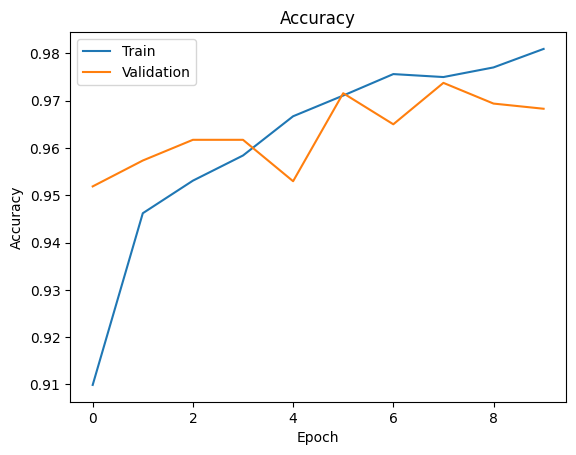

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
model.evaluate(test_dataset)

58/58 ━━━━━━━━━━━━━━━━━━━━ 29s 495ms/step - accuracy: 0.9420 - loss: 0.1565 - precision_1: 0.9181 - recall_1: 0.9745


[0.15646125376224518,
 0.9419813752174377,
 0.9180819392204285,
 0.9745492935180664]

Milestone

In [ ]:
model.save("collar_classifier.keras")

In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model("collar_classifier.keras")

### **Short & Long Pants**

In [ ]:
shorts = []

for x in os.listdir("archive/Clothes_Dataset/Celana_Pendek/"):
    shorts.append("archive/Clothes_Dataset/Celana_Pendek/" + x)



In [ ]:
longs = []

for x in os.listdir("archive/Clothes_Dataset/Celana_Panjang"):
    longs.append("archive/Clothes_Dataset/Celana_Panjang/" + x)



In [ ]:

dfshort = pd.DataFrame({
    "imagePath": shorts,
    "label": 0
})

dflong = pd.DataFrame({
    "imagePath": longs,
    "label": 1
})



In [ ]:
print(dfshort.head(3))

print(dflong.head(3))

                                           imagePath  label
0  archive/Clothes_Dataset/Celana_Pendek/00f4bb77...      0
1  archive/Clothes_Dataset/Celana_Pendek/celana_p...      0
2  archive/Clothes_Dataset/Celana_Pendek/71238a2e...      0
                                           imagePath  label
0  archive/Clothes_Dataset/Celana_Panjang/celana_...      1
1  archive/Clothes_Dataset/Celana_Panjang/celana_...      1
2  archive/Clothes_Dataset/Celana_Panjang/celana_...      1


In [ ]:
dfls = pd.concat([dfshort, dflong])
print(len(dfls))

1000


In [ ]:
df_train, df_test = train_test_split(
    dfls,
    test_size=0.2,
    train_size=0.8,
    shuffle=True,
    stratify=dfls['label'],
    random_state=42
)

In [ ]:
print(len(df_train))
print(len(df_test))

800
200


In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        df_train['imagePath'].values,
        df_train['label'].values
    )
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        df_test['imagePath'].values,
        df_test['label'].values
    )
)

In [ ]:
train_dataset = train_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.map(preprocess_image,num_parallel_calls=tf.data.AUTOTUNE)

# Batch = 32
train_dataset = train_dataset.batch(32)
test_dataset = test_dataset.batch(32)

# siapkan training berikutnya sebelum batch saat ini selesai
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [ ]:
base_model.trainable = 0

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(1/12),
    layers.RandomZoom(10/100)
])

In [ ]:

model = Sequential()


model.add(layers.Input(shape=(224,224,3), batch_size=32))

model.add(data_augmentation)
model.add(base_model)


model.add(layers.GlobalAveragePooling2D())

model.add(layers.Dense(128, activation='relu'))

model.add(layers.Dropout(0.5))

model.add(layers.Dense(1,activation='sigmoid'))


model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (32, 7, 7, 1280)       │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (32, 1280)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (32, 128)              │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (32, 1)                │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [ ]:
history = model.fit(
    train_dataset,
    epochs=10)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 542ms/step - accuracy: 0.9575 - loss: 0.1412 - precision_3: 0.9645 - recall_3: 0.9500
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 521ms/step - accuracy: 0.9638 - loss: 0.1042 - precision_3: 0.9696 - recall_3: 0.9575
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 521ms/step - accuracy: 0.9425 - loss: 0.1300 - precision_3: 0.9447 - recall_3: 0.9400
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 517ms/step - accuracy: 0.9625 - loss: 0.1145 - precision_3: 0.9719 - recall_3: 0.9525
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 557ms/step - accuracy: 0.9613 - loss: 0.1020 - precision_3: 0.9601 - recall_3: 0.9625
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 534ms/step - accuracy: 0.9550 - loss: 0.1226 - precision_3: 0.9619 - recall_3: 0.9475
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 530ms/step - accuracy: 0.9663 - loss: 0.0834 - precision_3: 0.9698 - recall_3: 0.9625
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 529ms/step - accuracy: 0.9625 - loss: 0.0951 - precision_3: 0.

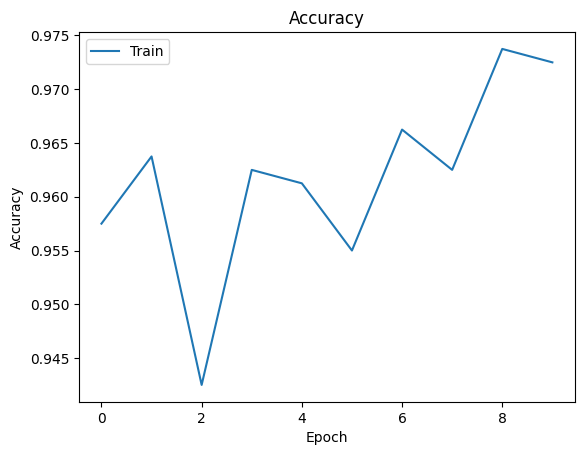

In [ ]:
plt.plot(history.history['accuracy'])

plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train'])

plt.show()

In [ ]:
model.evaluate(test_dataset)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 383ms/step - accuracy: 0.9350 - loss: 0.1711 - precision_3: 0.9888 - recall_3: 0.8800


[0.17109042406082153,
 0.9350000023841858,
 0.9887640476226807,
 0.8799999952316284]

In [ ]:
model.save("pants_classifier.keras")

In [ ]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (32, 7, 7, 1280)       │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (32, 1280)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (32, 128)              │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (32, 1)                │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,750,277 (10.49 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 328,196 (1.25 MB)

In [ ]:


y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)


    print("predik")
    print(preds)
    print(preds.flatten())
    preds = (preds > 0.5).astype(int)

    print("label")
    print(labels)
    print(labels.numpy())
    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

print(y_true)
confmtrx = confusion_matrix(y_true, y_pred)

confmtrx

predik
[[9.9998206e-01]
 [2.7404453e-03]
 [3.9729422e-01]
 [6.8761860e-03]
 [9.9809265e-01]
 [9.9984133e-01]
 [9.9998552e-01]
 [9.5870280e-01]
 [4.3664229e-04]
 [2.4920795e-03]
 [9.9991506e-01]
 [9.9276894e-01]
 [9.0436715e-01]
 [1.5910752e-03]
 [3.6538346e-05]
 [2.3359020e-04]
 [9.9927723e-01]
 [9.1377355e-02]
 [9.9999046e-01]
 [7.6551840e-04]
 [9.9999434e-01]
 [7.1400399e-03]
 [9.9999905e-01]
 [4.2559132e-02]
 [9.9995935e-01]
 [9.9999970e-01]
 [9.9999028e-01]
 [4.0730202e-01]
 [1.7060967e-03]
 [9.6285951e-01]
 [5.2740698e-04]
 [9.9952036e-01]]
[9.9998206e-01 2.7404453e-03 3.9729422e-01 6.8761860e-03 9.9809265e-01
 9.9984133e-01 9.9998552e-01 9.5870280e-01 4.3664229e-04 2.4920795e-03
 9.9991506e-01 9.9276894e-01 9.0436715e-01 1.5910752e-03 3.6538346e-05
 2.3359020e-04 9.9927723e-01 9.1377355e-02 9.9999046e-01 7.6551840e-04
 9.9999434e-01 7.1400399e-03 9.9999905e-01 4.2559132e-02 9.9995935e-01
 9.9999970e-01 9.9999028e-01 4.0730202e-01 1.7060967e-03 9.6285951e-01
 5.2740698e-04 9.99520

array([[99,  1],
       [12, 88]])